# Global Energy Transition Trends

**DSCI 235 — Final Project**

GitHub repo: https://github.com/vincema8/DSCI235-Final

## Introduction

This project looks at how countries are shifting from fossil fuels to renewables. The data comes from the [Our World in Data energy dataset](https://www.kaggle.com/datasets/pralabhpoudel/world-energy-consumption) on Kaggle, with sources including the Energy Institute, the U.S. EIA, and Ember. It has one row per country per year (1900–2022) and over 100 columns covering energy by source, electricity mix, GDP, and population.

### Questions

1. Which countries increased their renewable share the fastest over the past 20 years?
2. Is there a relationship between GDP per capita and renewable share?
3. How do the energy mixes of similarly sized economies compare (Germany vs Japan)?
4. Are renewables replacing fossil fuels or just covering additional demand?

Analysis is capped at 1965 onward since pre-1965 renewables data is sparse.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Loading and preparing the data

In [2]:
# load directly from the GitHub repo so the notebook is self-contained
url = 'https://raw.githubusercontent.com/vincema8/DSCI235-Final/main/World%20Energy%20Consumption.csv'
df = pd.read_csv(url)
print('shape:', df.shape)
df.head(3)

shape: (22012, 129)


,country,year,iso_code,population,gdp,biofuel_cons_change_pct,biofuel_cons_change_twh,biofuel_cons_per_capita,biofuel_consumption,biofuel_elec_per_capita,...,solar_share_elec,solar_share_energy,wind_cons_change_pct,wind_cons_change_twh,wind_consumption,wind_elec_per_capita,wind_electricity,wind_energy_per_capita,wind_share_elec,wind_share_energy
0,ASEAN (Ember),2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
1,ASEAN (Ember),2001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
2,ASEAN (Ember),2002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN


In [3]:
# keep only the columns we need
cols = ['country', 'year', 'iso_code', 'population', 'gdp',
        'fossil_fuel_consumption', 'renewables_consumption',
        'fossil_share_energy', 'renewables_share_energy',
        'coal_share_energy', 'oil_share_energy', 'gas_share_energy',
        'nuclear_share_energy', 'hydro_share_energy',
        'solar_share_energy', 'wind_share_energy', 'biofuel_share_energy',
        'primary_energy_consumption']
df = df[cols]

# real countries only (regional aggregates have empty iso_code)
# 'World' is kept separately for global totals
world = df[df['country'] == 'World'].copy()
countries = df[df['iso_code'].notna()].copy()

# cap at 1965 onward
countries = countries[countries['year'] >= 1965]
world = world[world['year'] >= 1965]

print('country rows:', len(countries), '| countries:', countries['country'].nunique())
print('world rows:', len(world))

country rows: 10532 | countries: 219
world rows: 58


## Q1. Which countries increased their renewable share fastest over the past 20 years?

I take the renewable share of primary energy in 2002 and 2022 for each country, compute the change in percentage points, and rank.

In [4]:
# pivot so each row is a country with 2002 and 2022 columns
rs = countries[countries['year'].isin([2002, 2022])]
rs = rs.pivot(index='country', columns='year', values='renewables_share_energy')
rs = rs.dropna()  # need both endpoints
rs['change_pp'] = rs[2022] - rs[2002]

top15 = rs.sort_values('change_pp', ascending=False).head(15)
top15

year,2002,2022,change_pp
country,,,
Denmark,8.587,43.043,34.456
Finland,16.365,38.497,22.132
Sweden,32.522,53.312,20.790
Portugal,9.749,28.967,19.218
United Kingdom,1.288,19.338,18.050
Ireland,2.235,20.132,17.897
Germany,3.539,21.258,17.719
Greece,2.783,19.892,17.109
Estonia,0.185,15.265,15.080


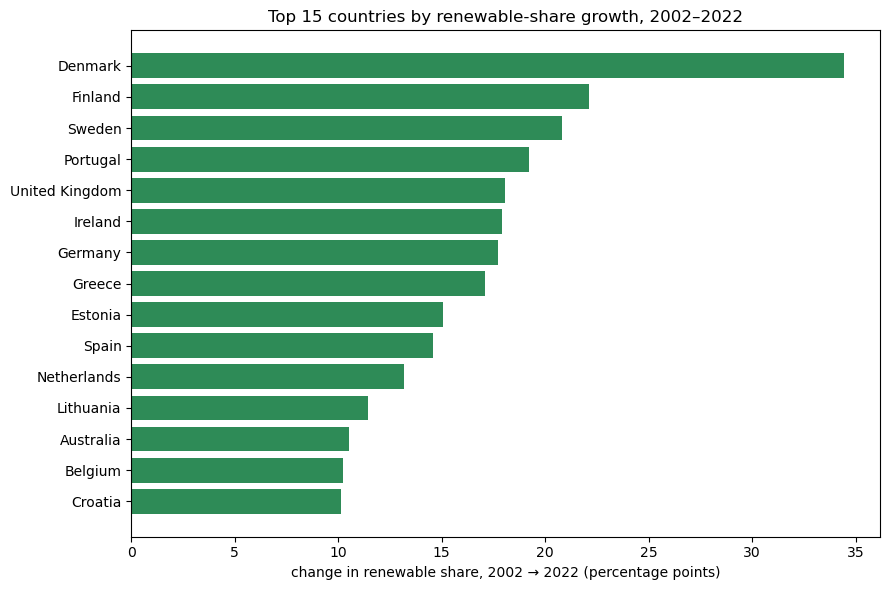

In [5]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top15.index[::-1], top15['change_pp'][::-1], color='seagreen')
ax.set_xlabel('change in renewable share, 2002 → 2022 (percentage points)')
ax.set_title('Top 15 countries by renewable-share growth, 2002–2022')
plt.tight_layout()
plt.show()

**Findings:** The fastest movers are a mix of small Northern European countries (Denmark, Sweden, Finland) that already had a renewables base and pushed it higher, and a few rapidly modernising economies. The change is in *percentage points of the energy mix*, so a country going from 10% to 40% renewables shows a 30pp jump even if total energy use also grew. That's worth keeping in mind when reading the chart — share growth doesn't mean fossil consumption fell.

## Q2. Is there a relationship between GDP per capita and renewable share?

I use 2018 since GDP coverage drops after that year in this dataset. GDP per capita is `gdp / population`.

In [6]:
y2018 = countries[countries['year'] == 2018].copy()
y2018['gdp_per_capita'] = y2018['gdp'] / y2018['population']
y2018 = y2018.dropna(subset=['gdp_per_capita', 'renewables_share_energy'])
print('countries with both values:', len(y2018))

countries with both values: 69


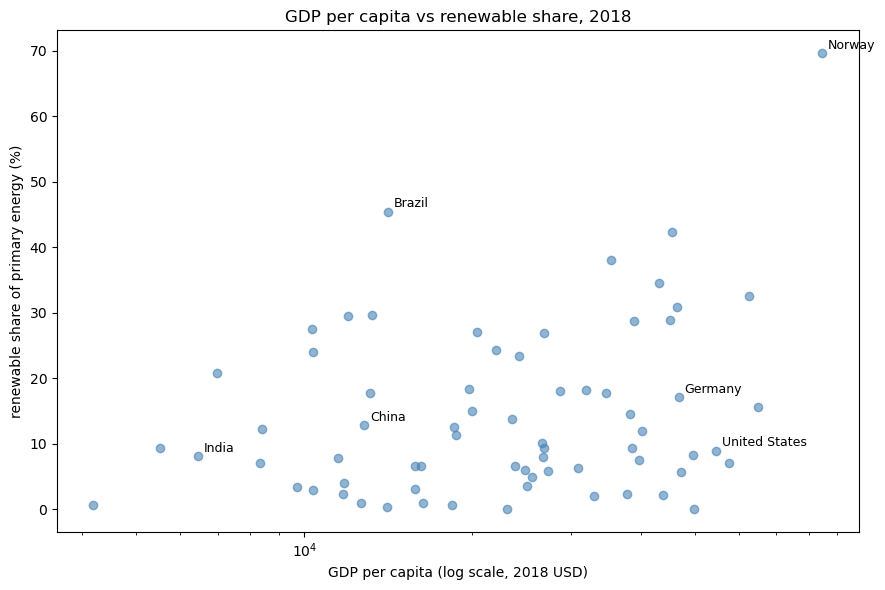

Pearson correlation (log GDP/capita, renewable share): 0.27


In [7]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(y2018['gdp_per_capita'], y2018['renewables_share_energy'],
           alpha=0.6, color='steelblue')
ax.set_xscale('log')
ax.set_xlabel('GDP per capita (log scale, 2018 USD)')
ax.set_ylabel('renewable share of primary energy (%)')
ax.set_title('GDP per capita vs renewable share, 2018')

# label a few notable points
for _, row in y2018.iterrows():
    if row['country'] in ['Norway', 'Iceland', 'Brazil', 'United States',
                          'China', 'India', 'Germany', 'Saudi Arabia']:
        ax.annotate(row['country'],
                    (row['gdp_per_capita'], row['renewables_share_energy']),
                    fontsize=9, xytext=(4, 3), textcoords='offset points')
plt.tight_layout()
plt.show()

corr = np.corrcoef(np.log(y2018['gdp_per_capita']),
                   y2018['renewables_share_energy'])[0, 1]
print(f'Pearson correlation (log GDP/capita, renewable share): {corr:.2f}')

**Findings:** The correlation is weakly positive (~0.27). Income level explains some of the variation in renewable share but not much. The high-renewable outliers (Norway, Iceland, Brazil) are countries with big hydro endowments — geography matters more than GDP. Several rich oil-exporting countries (Saudi Arabia) sit near zero renewables, and a few low-income countries score high because they rely on traditional biomass. Income alone doesn't explain renewable adoption.

## Q3. Germany vs Japan: how do the energy mixes compare?

Both are large industrialised G7 economies with limited fossil fuel reserves. Their policy paths since 2000 differ: Germany's *Energiewende* pushed renewables hard, while Japan saw nuclear collapse after Fukushima (2011).

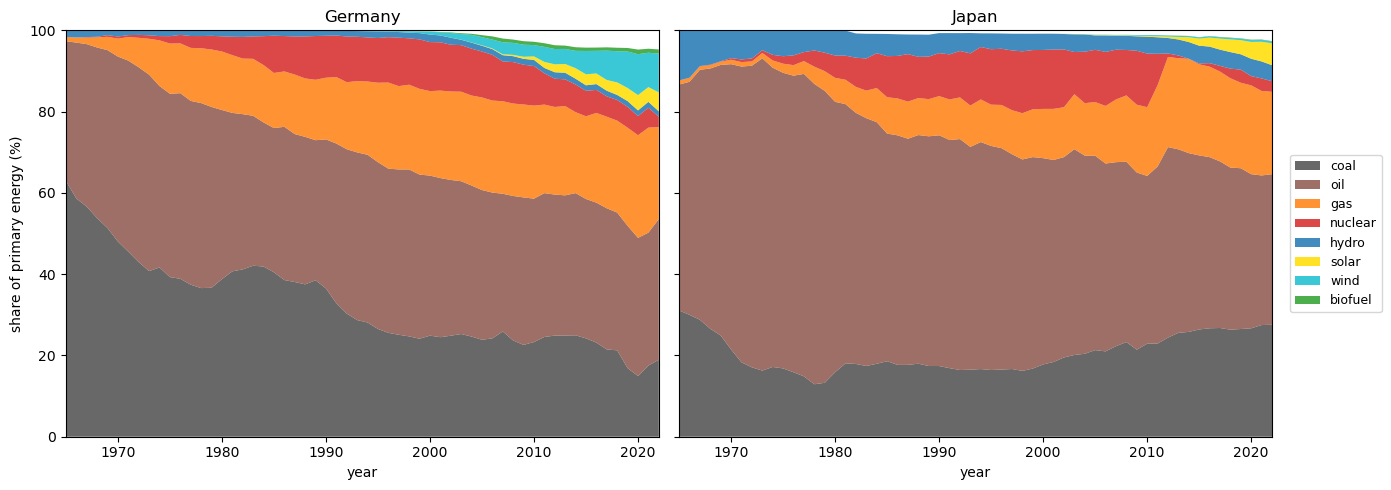

In [8]:
sources = ['coal_share_energy', 'oil_share_energy', 'gas_share_energy',
           'nuclear_share_energy', 'hydro_share_energy',
           'solar_share_energy', 'wind_share_energy', 'biofuel_share_energy']
labels = ['coal', 'oil', 'gas', 'nuclear', 'hydro', 'solar', 'wind', 'biofuel']
colors = ['#4d4d4d', '#8c564b', '#ff7f0e', '#d62728',
          '#1f77b4', '#ffdd00', '#17becf', '#2ca02c']

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, ctry in zip(axes, ['Germany', 'Japan']):
    sub = countries[countries['country'] == ctry].sort_values('year')
    ax.stackplot(sub['year'], [sub[s].fillna(0) for s in sources],
                 labels=labels, colors=colors, alpha=0.85)
    ax.set_title(ctry)
    ax.set_xlabel('year')
    ax.set_xlim(1965, 2022)
    ax.set_ylim(0, 100)
axes[0].set_ylabel('share of primary energy (%)')
axes[1].legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=9)
plt.tight_layout()
plt.show()

In [9]:
# numerical comparison for 2022
latest = countries[(countries['country'].isin(['Germany', 'Japan'])) &
                   (countries['year'] == 2022)]
latest[['country'] + sources].set_index('country').round(1)

,coal_share_energy,oil_share_energy,gas_share_energy,nuclear_share_energy,hydro_share_energy,solar_share_energy,wind_share_energy,biofuel_share_energy
country,,,,,,,,
Germany,18.9,34.6,22.6,2.5,1.3,4.6,9.6,1.0
Japan,27.6,37.0,20.3,2.6,3.9,5.4,0.4,0.1


**Findings:** Germany's mix shifts visibly toward wind and solar after 2000, with coal and nuclear shrinking. Japan looks flatter — oil dominated through the 1970s, gas and nuclear grew, then nuclear collapsed after 2011 and the gap was filled mostly by gas and coal rather than renewables (note this is share of the energy mix, not absolute consumption — Japan's total energy demand fell over the same period as population declined). By 2022 Germany has a noticeably higher renewable share than Japan despite similar economic size, which lines up with Germany's stronger policy push.

## Q4. Are renewables replacing fossil fuels or just covering additional demand?

Globally and for a few selected countries, I plot fossil fuel consumption and renewables consumption side by side. If fossil consumption is flat or falling while renewables grow, that's replacement. If both rise, renewables are mostly covering new demand.

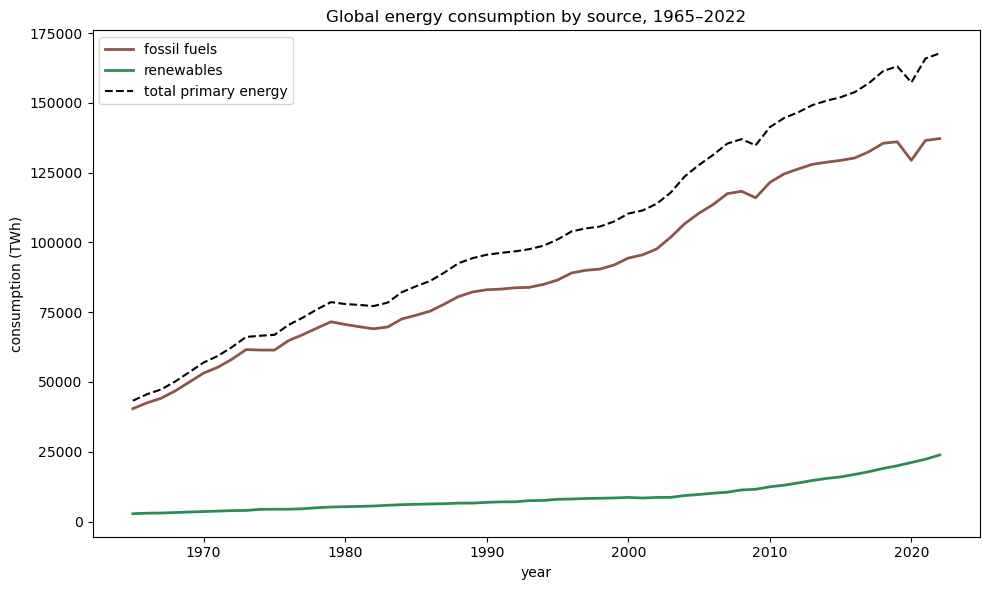

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))
w = world.sort_values('year')
ax.plot(w['year'], w['fossil_fuel_consumption'], label='fossil fuels',
        color='#8c564b', linewidth=2)
ax.plot(w['year'], w['renewables_consumption'], label='renewables',
        color='seagreen', linewidth=2)
ax.plot(w['year'], w['primary_energy_consumption'], label='total primary energy',
        color='black', linestyle='--', linewidth=1.5)
ax.set_xlabel('year')
ax.set_ylabel('consumption (TWh)')
ax.set_title('Global energy consumption by source, 1965–2022')
ax.legend()
plt.tight_layout()
plt.show()

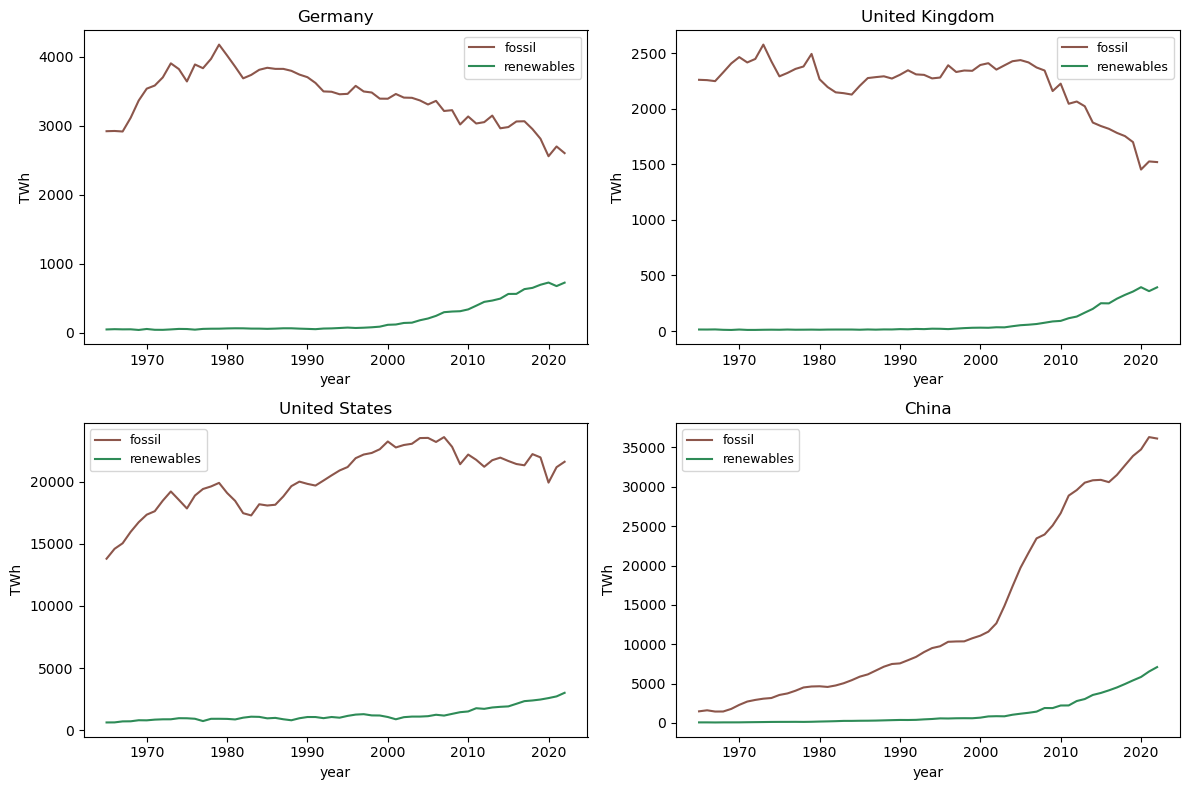

In [11]:
# country-level view for a few notable cases
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, ctry in zip(axes.flat, ['Germany', 'United Kingdom', 'United States', 'China']):
    sub = countries[countries['country'] == ctry].sort_values('year')
    ax.plot(sub['year'], sub['fossil_fuel_consumption'],
            label='fossil', color='#8c564b')
    ax.plot(sub['year'], sub['renewables_consumption'],
            label='renewables', color='seagreen')
    ax.set_title(ctry)
    ax.set_xlabel('year')
    ax.set_ylabel('TWh')
    ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [12]:
# numerical: change in fossil and renewables consumption, 2002–2022
delta = countries[countries['year'].isin([2002, 2022])]
delta = delta.pivot(index='country', columns='year',
                    values=['fossil_fuel_consumption', 'renewables_consumption'])
delta.columns = ['fossil_2002', 'fossil_2022', 'renew_2002', 'renew_2022']
delta = delta.dropna()
delta['fossil_change'] = delta['fossil_2022'] - delta['fossil_2002']
delta['renew_change'] = delta['renew_2022'] - delta['renew_2002']

# countries where fossil actually fell (replacement) vs rose (added demand)
replacing = delta[delta['fossil_change'] < 0].sort_values('renew_change', ascending=False)
adding = delta[delta['fossil_change'] > 0].sort_values('renew_change', ascending=False)
print(f'countries where fossil consumption FELL 2002–2022: {len(replacing)}')
print(f'countries where fossil consumption ROSE 2002–2022: {len(adding)}')
print('\nTop 10 "replacers" (fossil down, renewables up):')
replacing[['fossil_change', 'renew_change']].head(10).round(0)

countries where fossil consumption FELL 2002–2022: 33
countries where fossil consumption ROSE 2002–2022: 33

Top 10 "replacers" (fossil down, renewables up):


,fossil_change,renew_change
country,,
United States,-1347.0,1959.0
Germany,-805.0,584.0
United Kingdom,-832.0,359.0
Japan,-815.0,329.0
Spain,-219.0,232.0
France,-446.0,148.0
Italy,-519.0,142.0
Netherlands,-191.0,129.0
Sweden,-76.0,128.0


**Findings:** Globally, fossil fuel consumption is still rising. Renewables have grown sharply since 2000 but total energy demand grew alongside, so at the global level renewables are mostly covering *additional* demand rather than displacing fossil use. The country-level picture is split almost exactly in half: of the 66 countries with full data, 33 saw fossil consumption fall between 2002 and 2022 and 33 saw it rise. The fallers are mostly wealthy economies — the US tops the list (fossil down ~1,350 TWh while renewables grew ~1,960 TWh), followed by Germany, the UK, Japan, France, and Italy. The risers are dominated by big growing emitters like China and India where renewables grew massively but fossil consumption grew even more in absolute terms. So the answer depends on which country you look at, and at the global aggregate it's still mostly *additional*, not *replacement*.

## Conclusions

- **Q1:** A small set of mostly Northern European countries leads on renewable-share growth over the past 20 years, with Denmark, Sweden, and Finland near the top. Share growth is partly a measurement effect — the ratio can rise without fossil consumption falling.
- **Q2:** GDP per capita and renewable share are weakly correlated. Geography (hydro potential) and policy explain more than income does.
- **Q3:** Germany and Japan started from similar mixes but diverged sharply post-2000. Germany pivoted to wind and solar; Japan's nuclear collapse was filled by fossil fuels in *share* terms rather than renewables, though absolute fossil use fell as total energy demand contracted.
- **Q4:** Globally, renewables are mostly covering new demand rather than replacing fossil fuels. Most wealthy economies (US, Germany, UK, Japan, France) are genuine replacers in absolute terms; the bulk of new fossil consumption growth comes from emerging economies like China and India.

## Limitations and things that would need more time

- **GDP coverage stops at 2018** in this dataset, so the income–renewables comparison is dated.
- **"Renewables" includes traditional biomass** in some country reporting, which inflates the renewable share for low-income countries in a way that doesn't really reflect modern clean-energy adoption. Splitting modern renewables (solar, wind) from hydro and biomass would sharpen Q2.
- **The replacement-vs-additional analysis is descriptive, not causal.** A proper version would account for population growth, economic structure shifts (manufacturing offshoring), and energy efficiency gains.
- **Country-year coverage is uneven.** Some countries only have data starting in the 1980s or 1990s, so the 2002 baseline for Q1 excludes some interesting cases.